# Configuration

In [176]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [2]:
from scipy.stats import norm

# estimators
from econml.grf import CausalForest

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Main

In [195]:
num_obs = 1000  # number of observations
num_covariates = 10  # number of covariates

# generate covariates
relu_te_func = lambda x: np.maximum(x[:, 0], 0)  # true treatment effect function

def sample1(te_func: callable, sample_size: int, seed: int = None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # generate covariates
    X_arr = np.random.normal(size=(sample_size, num_covariates))  # Gaussian covariates with shape = (sample_size, num_covariates)
    W_arr = np.random.binomial(1, 0.5, size=(sample_size, ))  # binary treatment, shape = (sample_size, 1)

    Y_arr = te_func(X_arr) * W_arr + X_arr[:, 1] + np.maximum(X_arr[:, 2], 0) + np.random.normal(size=(sample_size, ))  # outcome, shape = (sample_size, 1)

    return X_arr, W_arr, Y_arr


In [196]:
te_func = relu_te_func   # true treatment effect function

# generate training samples
X_arr, W_arr, Y_arr = sample1(te_func, num_obs, seed=123)

# define causal forest
cf = CausalForest()

# fit causal forest
cf.fit(X=X_arr, T=W_arr, y=Y_arr)

# in sample performance
train_performance_df = pd.DataFrame({
    'tau_pred': cf.oob_predict(X_arr).flatten(),
    'tau_true': te_func(X_arr)
})

train_rmse = np.mean((train_performance_df['tau_pred'] - train_performance_df['tau_true']) ** 2) ** 0.5
print(f'Train RMSE: {train_rmse:.2f}')


# generate test samples
X_test_arr, W_test_arr, Y_test_arr = sample1(te_func, num_obs)

# out of sample performance
test_performance_df = pd.DataFrame({
    'tau_pred': cf.predict(X_test_arr).flatten(),
    'tau_true': te_func(X_test_arr)
})
# get estimator variance 
_, tau_var = cf.predict_and_var(X_test_arr)
tau_var = tau_var.flatten()
# get confidence intervals
alpha = 0.05
phi = norm.ppf(1 - alpha / 2)
test_performance_df.insert(2, 'tau_ci_lb', test_performance_df['tau_pred'] - phi * np.sqrt(tau_var))
test_performance_df.insert(3, 'tau_ci_ub', test_performance_df['tau_pred'] + phi * np.sqrt(tau_var))
test_performance_df.insert(4, 'is_significant', (test_performance_df['tau_ci_lb'] > 0) | (test_performance_df['tau_ci_ub'] < 0))

# calculate performance metrics
test_rmse = np.mean((test_performance_df['tau_pred'] - test_performance_df['tau_true']) ** 2) ** 0.5

print(f'\nTest RMSE: {test_rmse:.2f}')
print('Test set 95% significant coverage: {:.2%}\n'.format(test_performance_df['is_significant'].mean()))

Train RMSE: 0.39

Test RMSE: 0.40
Test set 95% significant coverage: 48.50%



In [177]:
# decision making
num_obs = 500
budget = 100
num_repeats = 1000
clairvoyant_list = [None for _ in range(num_repeats)]
cf_eto_list = [None for _ in range(num_repeats)]
cf_ucb_list = [None for _ in range(num_repeats)]
cf_lcb_list = [None for _ in range(num_repeats)]

for i in tqdm(range(num_repeats)):
    X_arr, _, _ = sample1(te_func, num_obs)

    # get treatment effect and its variance
    tau_pred, tau_var = cf.predict_and_var(X_arr)
    tau_pred, tau_var = tau_pred.flatten(), tau_var.flatten()
    te_true = te_func(X_arr)

    clairvoyant_list[i] = np.sort(te_true)[-budget:].sum()
    cf_eto_list[i] = te_true[np.argsort(-tau_pred)[-budget:]].sum()
    cf_ucb_list[i] = te_true[np.argsort(-tau_pred - phi * np.sqrt(tau_var))[-budget:]].sum()
    cf_lcb_list[i] = te_true[np.argsort(-tau_pred + phi * np.sqrt(tau_var))[-budget:]].sum()

    # print('Clairvoyant targeting objective: {:.2f}'.format(optimal_targeting_obj))
    # print('Causal forest targeting objective: {:.2f}'.format(cf_targeting_obj))
    # print('Causal forest UCB targeting objective: {:.2f}'.format(cf_ucb_targeting_obj))
    # print('Causal forest LCB targeting objective: {:.2f}'.format(cf_lcb_targeting_obj))

result_df = pd.DataFrame({
    'clairvoyant': clairvoyant_list,
    'cf_eto': cf_eto_list,
    'cf_ucb': cf_ucb_list,
    'cf_lcb': cf_lcb_list
})

100%|██████████| 1000/1000 [00:28<00:00, 34.88it/s]


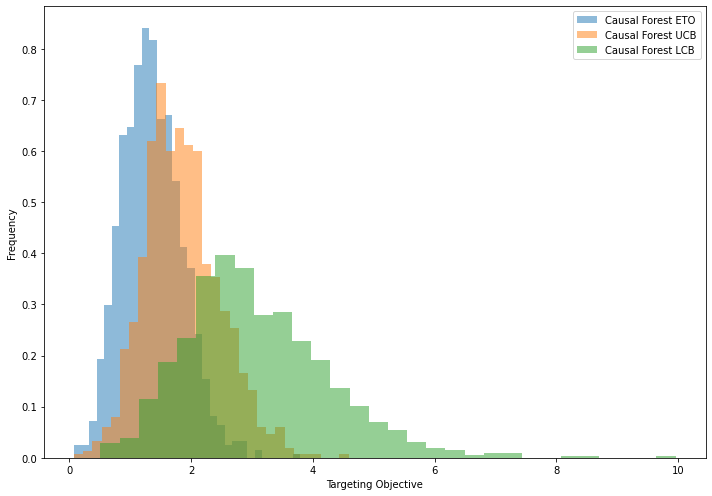

       clairvoyant       cf_eto       cf_ucb       cf_lcb
count  1000.000000  1000.000000  1000.000000  1000.000000
mean    140.053695     1.363851     1.855567     3.085730
std       6.537526     0.491258     0.618381     1.198953
min     120.299390     0.080484     0.080484     0.511876
25%     135.562079     1.015418     1.428116     2.239431
50%     140.004396     1.333844     1.797690     2.890400
75%     144.463878     1.674545     2.237246     3.772361
max     168.648425     3.791509     4.585542     9.954448


In [179]:
fig, ax = plt.subplots(figsize=(10, 7))

# ax.hist(clairvoyant_list, bins=30, alpha=0.5, label='Clairvoyant')
ax.hist(cf_eto_list, bins=30, alpha=0.5, density=True, label='Causal Forest ETO')
ax.hist(cf_ucb_list, bins=30, alpha=0.5, density=True, label='Causal Forest UCB')
ax.hist(cf_lcb_list, bins=30, alpha=0.5, density=True, label='Causal Forest LCB')

ax.set_xlabel('Targeting Objective')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(result_df.describe())